In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
import pathlib
from PIL import Image

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

try:
    BASE_DIR = pathlib.Path(__file__).parent
except NameError:
    BASE_DIR = pathlib.Path.cwd()

DATA_ROOT = BASE_DIR / "dataset"

# Гиперпараметры для эксперимента
CONFIG = {
    'batch_size': 16,
    'learning_rate': 0.001,
    'momentum': 0.9,
    'num_epochs': 10,
    'mode': 'finetune',  # 'finetune' или 'feature_extract'
    'experiment_name': 'exp1_default'
}

cudnn.benchmark = True
plt.ion()

# --- 2. ПРЕПРОЦЕССИНГ ДАННЫХ ---
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([  # Для теста только нормализация
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Загрузка всего датасета из корня

full_dataset = datasets.ImageFolder(DATA_ROOT, data_transforms['train'])

image_datasets = {}
for x in ['train', 'val', 'test']:
    dir_path = DATA_ROOT / x
    if dir_path.exists():
        image_datasets[x] = datasets.ImageFolder(dir_path, data_transforms[x])
    else:
        print(f"Warning: Directory {dir_path} not found. Using random split logic needed.")

dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], 
                                              batch_size=CONFIG['batch_size'], 
                                              shuffle=True, num_workers=2)
               for x in ['train', 'val', 'test']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes
print(f"Classes found: {class_names}")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

# --- 3. ФУНКЦИИ ВИЗУАЛИЗАЦИИ И ОБУЧЕНИЯ ---
def imshow(inp, title=None, ax=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    if ax is None:
        plt.imshow(inp)
        if title: plt.title(title)
        plt.pause(0.001)
    else:
        ax.imshow(inp)
        if title: ax.set_title(title)
        ax.axis('off')

def train_model(model, criterion, optimizer, scheduler, num_epochs=25, phase_name='train'):
    since = time.time()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1} | {phase_name}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = (running_corrects.double() / dataset_sizes[phase]).cpu()
            
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            # Сохраняем историю для графиков
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc)

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        
        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model, history

def plot_history(history, title="Metrics"):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

def evaluate_test(model):
    model.eval()
    correct = 0
    total = 0
    class_correct = [0] * len(class_names)
    class_total = [0] * len(class_names)
    
    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            c = (predicted == labels).squeeze()
            
            for i in range(labels.size(0)):
                label = labels[i]
                class_correct[label] += c[i].item()
                class_total[label] += 1
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    print(f'\nTest Accuracy: {100 * correct / total:.2f}%')
    for i in range(len(class_names)):
        if class_total[i] > 0:
            print(f'Accuracy of {class_names[i]:12s}: {100 * class_correct[i] / class_total[i]:.2f}%')

# --- 4. СОЗДАНИЕ МОДЕЛИ ---
def create_model(mode='finetune', num_classes=4, model_name='resnet18'):
    if model_name == 'resnet18':
        model = torchvision.models.resnet18(weights='IMAGENET1K_V1')
    elif model_name == 'resnet50':
        model = torchvision.models.resnet50(weights='IMAGENET1K_V1')
    
    if mode == 'feature_extract':
        for param in model.parameters():
            param.requires_grad = False
    
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model.to(device)

# --- 5. ЗАПУСК ЭКСПЕРИМЕНТА ---
def create_dataloaders(batch_size):
    """Создаёт новые dataloaders с указанным batch_size"""
    dataloaders = {x: torch.utils.data.DataLoader(
        image_datasets[x], 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=2
    ) for x in ['train', 'val', 'test']}
    return dataloaders

def run_experiment(config):
    print(f"\n>>> Running experiment: {config['experiment_name']}")
    
    # Пересоздаем dataloaders с новым batch_size
    global dataloaders, dataset_sizes
    dataloaders = create_dataloaders(config['batch_size'])
    dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
    
    model = create_model(mode=config['mode'], num_classes=len(class_names))
    criterion = nn.CrossEntropyLoss()
    
    # Оптимизируем только те параметры, которые требуют градиента
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), 
                          lr=config['learning_rate'], momentum=config['momentum'])
    scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
    
    model_trained, history = train_model(model, criterion, optimizer, scheduler, 
                                         num_epochs=config['num_epochs'], 
                                         phase_name=config['experiment_name'])
    
    plot_history(history, title=config['experiment_name'])
    evaluate_test(model_trained)
    
    return history



CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Ti
Classes found: ['kirby', 'pink panther', 'pinkie pie', 'slowpoke']
Using cuda:0 device



>>> Running experiment: exp1_default
Epoch 0/9 | exp1_default
----------
train Loss: 1.2299 Acc: 0.4478
val Loss: 0.8213 Acc: 0.7288

Epoch 1/9 | exp1_default
----------
train Loss: 0.5910 Acc: 0.8586
val Loss: 0.4094 Acc: 0.9153

Epoch 2/9 | exp1_default
----------
train Loss: 0.3955 Acc: 0.8855
val Loss: 0.2639 Acc: 0.8983

Epoch 3/9 | exp1_default
----------
train Loss: 0.3679 Acc: 0.8620
val Loss: 0.1739 Acc: 0.9492

Epoch 4/9 | exp1_default
----------
train Loss: 0.2772 Acc: 0.9024
val Loss: 0.1632 Acc: 0.9661

Epoch 5/9 | exp1_default
----------
train Loss: 0.2866 Acc: 0.9057
val Loss: 0.1506 Acc: 0.9831

Epoch 6/9 | exp1_default
----------
train Loss: 0.1842 Acc: 0.9461
val Loss: 0.1300 Acc: 0.9661

Epoch 7/9 | exp1_default
----------
train Loss: 0.1634 Acc: 0.9495
val Loss: 0.1310 Acc: 0.9661

Epoch 8/9 | exp1_default
----------
train Loss: 0.1717 Acc: 0.9428
val Loss: 0.1239 Acc: 0.9661

Epoch 9/9 | exp1_default
----------
train Loss: 0.1472 Acc: 0.9630
val Loss: 0.1238 Acc: 

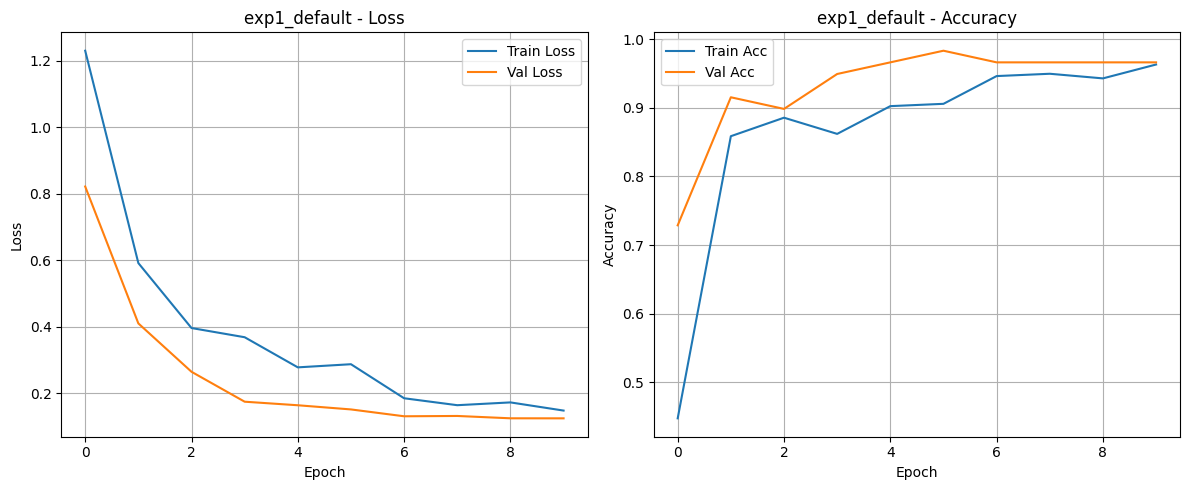


Test Accuracy: 97.50%
Accuracy of kirby       : 100.00%
Accuracy of pink panther: 100.00%
Accuracy of pinkie pie  : 100.00%
Accuracy of slowpoke    : 90.00%


In [11]:
# 1. Базовый запуск
run_experiment(CONFIG)
plt.show()

Исследование на другой архитектуре ResNet50


>>> Running experiment: arch_resnet50
Epoch 0/9 | arch_resnet50
----------
train Loss: 1.2509 Acc: 0.4343
val Loss: 0.7535 Acc: 0.7627

Epoch 1/9 | arch_resnet50
----------
train Loss: 0.6299 Acc: 0.7811
val Loss: 0.4979 Acc: 0.7966

Epoch 2/9 | arch_resnet50
----------
train Loss: 0.4205 Acc: 0.8687
val Loss: 0.2779 Acc: 0.9492

Epoch 3/9 | arch_resnet50
----------
train Loss: 0.2786 Acc: 0.9192
val Loss: 0.2059 Acc: 0.9492

Epoch 4/9 | arch_resnet50
----------
train Loss: 0.2551 Acc: 0.9024
val Loss: 0.1710 Acc: 0.9492

Epoch 5/9 | arch_resnet50
----------
train Loss: 0.2151 Acc: 0.9327
val Loss: 0.1338 Acc: 0.9661

Epoch 6/9 | arch_resnet50
----------
train Loss: 0.2225 Acc: 0.9394
val Loss: 0.1107 Acc: 0.9831

Epoch 7/9 | arch_resnet50
----------
train Loss: 0.1707 Acc: 0.9596
val Loss: 0.1082 Acc: 0.9831

Epoch 8/9 | arch_resnet50
----------
train Loss: 0.1295 Acc: 0.9663
val Loss: 0.1093 Acc: 0.9831

Epoch 9/9 | arch_resnet50
----------
train Loss: 0.1354 Acc: 0.9630
val Loss: 0

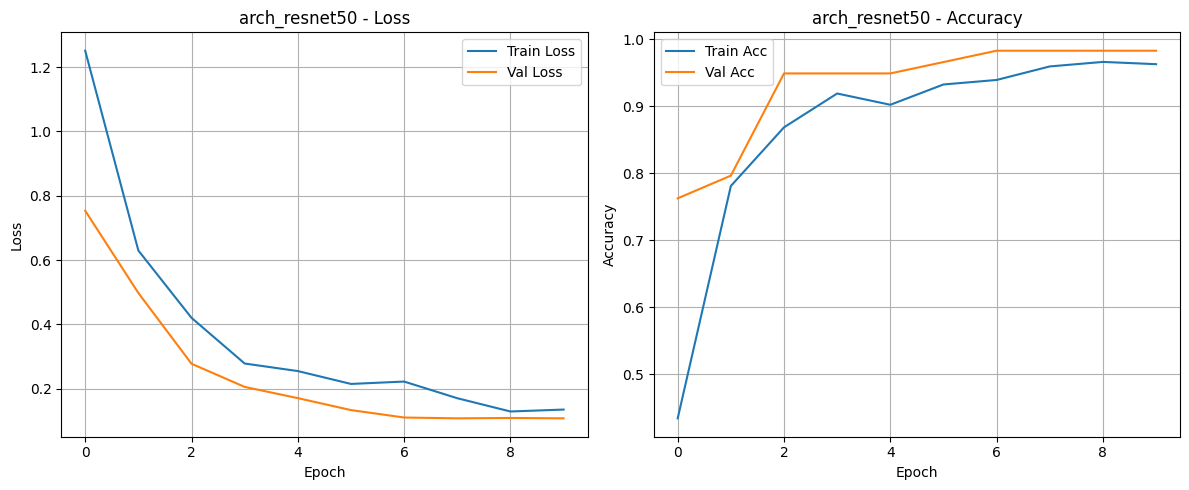


Test Accuracy: 97.50%
Accuracy of kirby       : 100.00%
Accuracy of pink panther: 100.00%
Accuracy of pinkie pie  : 100.00%
Accuracy of slowpoke    : 90.00%


{'train_loss': [1.2509162056727041,
  0.6299246730226459,
  0.4205494151271955,
  0.2785715567142474,
  0.25512120739779487,
  0.21511711636777678,
  0.22247114115291172,
  0.17070073421153958,
  0.1294757349021507,
  0.13543874627411967],
 'train_acc': [tensor(0.4343, dtype=torch.float64),
  tensor(0.7811, dtype=torch.float64),
  tensor(0.8687, dtype=torch.float64),
  tensor(0.9192, dtype=torch.float64),
  tensor(0.9024, dtype=torch.float64),
  tensor(0.9327, dtype=torch.float64),
  tensor(0.9394, dtype=torch.float64),
  tensor(0.9596, dtype=torch.float64),
  tensor(0.9663, dtype=torch.float64),
  tensor(0.9630, dtype=torch.float64)],
 'val_loss': [0.7535383933681553,
  0.49789199788691635,
  0.27790157724235015,
  0.20590016043792336,
  0.1709534029902543,
  0.1338290223630808,
  0.11070436112961526,
  0.10815675682940726,
  0.1093110096151546,
  0.10815581054253093],
 'val_acc': [tensor(0.7627, dtype=torch.float64),
  tensor(0.7966, dtype=torch.float64),
  tensor(0.9492, dtype=torch

In [12]:
run_experiment({**CONFIG, 'experiment_name': 'arch_resnet50', 'model_name': 'resnet50'})

Исследования Learning Rate


>>> Running experiment: exp_lr_high
Epoch 0/9 | exp_lr_high
----------
train Loss: 16.0041 Acc: 0.2660
val Loss: 165672.0434 Acc: 0.2542

Epoch 1/9 | exp_lr_high
----------
train Loss: 7.3985 Acc: 0.2727
val Loss: 1423.1608 Acc: 0.2373

Epoch 2/9 | exp_lr_high
----------
train Loss: 7.7113 Acc: 0.2525
val Loss: 15.8875 Acc: 0.2542

Epoch 3/9 | exp_lr_high
----------
train Loss: 2.2670 Acc: 0.2525
val Loss: 1.6610 Acc: 0.2373

Epoch 4/9 | exp_lr_high
----------
train Loss: 1.9439 Acc: 0.2862
val Loss: 2.5118 Acc: 0.1864

Epoch 5/9 | exp_lr_high
----------
train Loss: 1.5816 Acc: 0.2795
val Loss: 1.4741 Acc: 0.3220

Epoch 6/9 | exp_lr_high
----------
train Loss: 1.5117 Acc: 0.2525
val Loss: 1.3673 Acc: 0.3390

Epoch 7/9 | exp_lr_high
----------
train Loss: 1.3919 Acc: 0.2929
val Loss: 1.3321 Acc: 0.3220

Epoch 8/9 | exp_lr_high
----------
train Loss: 1.3784 Acc: 0.2828
val Loss: 1.3106 Acc: 0.3559

Epoch 9/9 | exp_lr_high
----------
train Loss: 1.3598 Acc: 0.3266
val Loss: 1.3068 Acc: 0

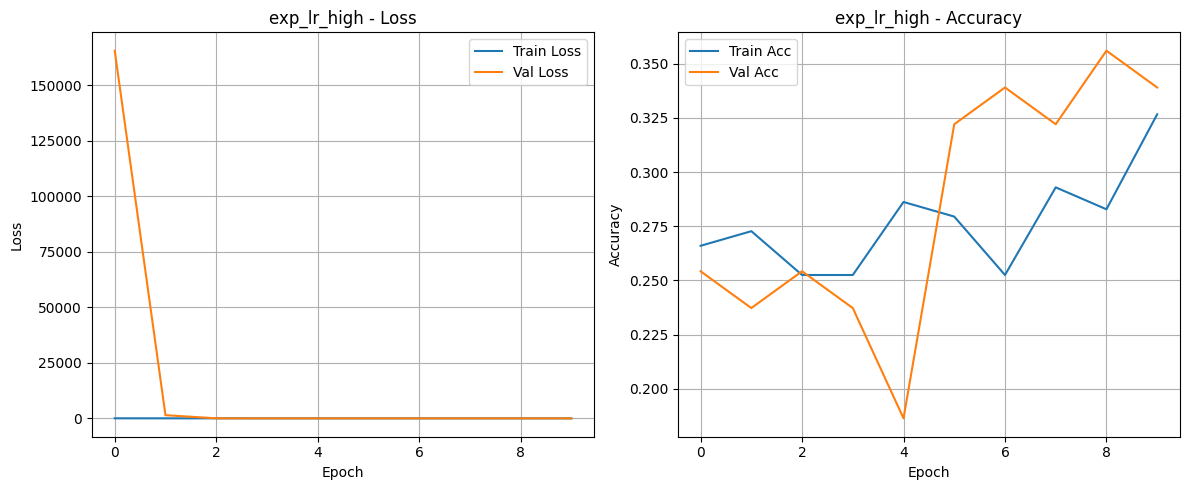


Test Accuracy: 35.00%
Accuracy of kirby       : 90.00%
Accuracy of pink panther: 50.00%
Accuracy of pinkie pie  : 0.00%
Accuracy of slowpoke    : 0.00%


{'train_loss': [16.00413529238717,
  7.398520344435567,
  7.71132197123184,
  2.2670406560705167,
  1.943911601397325,
  1.5815816925029562,
  1.5116596149675774,
  1.39193789846568,
  1.378388225831568,
  1.3598076598812836],
 'train_acc': [tensor(0.2660, dtype=torch.float64),
  tensor(0.2727, dtype=torch.float64),
  tensor(0.2525, dtype=torch.float64),
  tensor(0.2525, dtype=torch.float64),
  tensor(0.2862, dtype=torch.float64),
  tensor(0.2795, dtype=torch.float64),
  tensor(0.2525, dtype=torch.float64),
  tensor(0.2929, dtype=torch.float64),
  tensor(0.2828, dtype=torch.float64),
  tensor(0.3266, dtype=torch.float64)],
 'val_loss': [165672.04343220338,
  1423.1607831534693,
  15.887526512145996,
  1.6609693523180686,
  2.5117825168674277,
  1.4741442324751515,
  1.3672849626864416,
  1.3320681988182714,
  1.3106300204487171,
  1.3068249407461134],
 'val_acc': [tensor(0.2542, dtype=torch.float64),
  tensor(0.2373, dtype=torch.float64),
  tensor(0.2542, dtype=torch.float64),
  tensor

In [13]:
run_experiment({**CONFIG, 'learning_rate': 0.1, 'experiment_name': 'exp_lr_high'}) #сильно большой


>>> Running experiment: exp_lr_low
Epoch 0/9 | exp_lr_low
----------
train Loss: 1.4435 Acc: 0.2323
val Loss: 1.5086 Acc: 0.1695

Epoch 1/9 | exp_lr_low
----------
train Loss: 1.3120 Acc: 0.4007
val Loss: 1.3224 Acc: 0.3729

Epoch 2/9 | exp_lr_low
----------
train Loss: 1.1738 Acc: 0.5589
val Loss: 1.1821 Acc: 0.5424

Epoch 3/9 | exp_lr_low
----------
train Loss: 1.0584 Acc: 0.6296
val Loss: 1.0661 Acc: 0.5763

Epoch 4/9 | exp_lr_low
----------
train Loss: 0.9354 Acc: 0.7239
val Loss: 0.9585 Acc: 0.6441

Epoch 5/9 | exp_lr_low
----------
train Loss: 0.8921 Acc: 0.7205
val Loss: 0.8772 Acc: 0.6780

Epoch 6/9 | exp_lr_low
----------
train Loss: 0.8370 Acc: 0.7710
val Loss: 0.8036 Acc: 0.7119

Epoch 7/9 | exp_lr_low
----------
train Loss: 0.7930 Acc: 0.7879
val Loss: 0.8075 Acc: 0.7119

Epoch 8/9 | exp_lr_low
----------
train Loss: 0.7686 Acc: 0.8081
val Loss: 0.8005 Acc: 0.7119

Epoch 9/9 | exp_lr_low
----------
train Loss: 0.7576 Acc: 0.8350
val Loss: 0.7852 Acc: 0.6949

Training compl

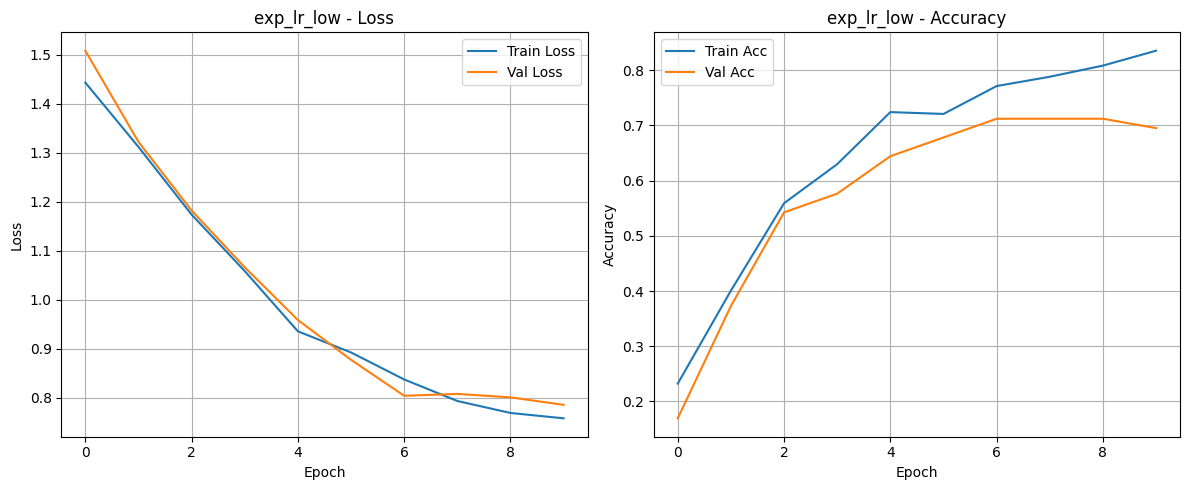


Test Accuracy: 80.00%
Accuracy of kirby       : 80.00%
Accuracy of pink panther: 80.00%
Accuracy of pinkie pie  : 90.00%
Accuracy of slowpoke    : 70.00%


{'train_loss': [1.4434691266178683,
  1.312009754807058,
  1.1737898652401035,
  1.0584029232211385,
  0.9353688106392369,
  0.8921474581615692,
  0.8369963831371732,
  0.7930291702450325,
  0.7686031250038532,
  0.7576176351569719],
 'train_acc': [tensor(0.2323, dtype=torch.float64),
  tensor(0.4007, dtype=torch.float64),
  tensor(0.5589, dtype=torch.float64),
  tensor(0.6296, dtype=torch.float64),
  tensor(0.7239, dtype=torch.float64),
  tensor(0.7205, dtype=torch.float64),
  tensor(0.7710, dtype=torch.float64),
  tensor(0.7879, dtype=torch.float64),
  tensor(0.8081, dtype=torch.float64),
  tensor(0.8350, dtype=torch.float64)],
 'val_loss': [1.5085675433530645,
  1.322361960249432,
  1.1821218183485127,
  1.0661213478799594,
  0.9584904606059447,
  0.8771547119496232,
  0.8036397968308401,
  0.8075323953466901,
  0.8004858514009896,
  0.7851874434341819],
 'val_acc': [tensor(0.1695, dtype=torch.float64),
  tensor(0.3729, dtype=torch.float64),
  tensor(0.5424, dtype=torch.float64),
  

In [15]:
run_experiment({**CONFIG, 'learning_rate': 0.0001, 'experiment_name': 'exp_lr_low'}) #сильно маленький

Исследование Batch Size


>>> Running experiment: exp_bs_32
Epoch 0/9 | exp_bs_32
----------
train Loss: 1.4921 Acc: 0.2694
val Loss: 1.2696 Acc: 0.3898

Epoch 1/9 | exp_bs_32
----------
train Loss: 1.0138 Acc: 0.5960
val Loss: 0.7524 Acc: 0.7966

Epoch 2/9 | exp_bs_32
----------
train Loss: 0.6214 Acc: 0.8283
val Loss: 0.5550 Acc: 0.7797

Epoch 3/9 | exp_bs_32
----------
train Loss: 0.5334 Acc: 0.8316
val Loss: 0.3550 Acc: 0.9153

Epoch 4/9 | exp_bs_32
----------
train Loss: 0.3593 Acc: 0.9125
val Loss: 0.3087 Acc: 0.8983

Epoch 5/9 | exp_bs_32
----------
train Loss: 0.3144 Acc: 0.9158
val Loss: 0.2465 Acc: 0.9492

Epoch 6/9 | exp_bs_32
----------
train Loss: 0.2205 Acc: 0.9630
val Loss: 0.2144 Acc: 0.9492

Epoch 7/9 | exp_bs_32
----------
train Loss: 0.2163 Acc: 0.9461
val Loss: 0.2084 Acc: 0.9492

Epoch 8/9 | exp_bs_32
----------
train Loss: 0.2302 Acc: 0.9495
val Loss: 0.2031 Acc: 0.9492

Epoch 9/9 | exp_bs_32
----------
train Loss: 0.2242 Acc: 0.9428
val Loss: 0.2025 Acc: 0.9492

Training complete in 1m 6

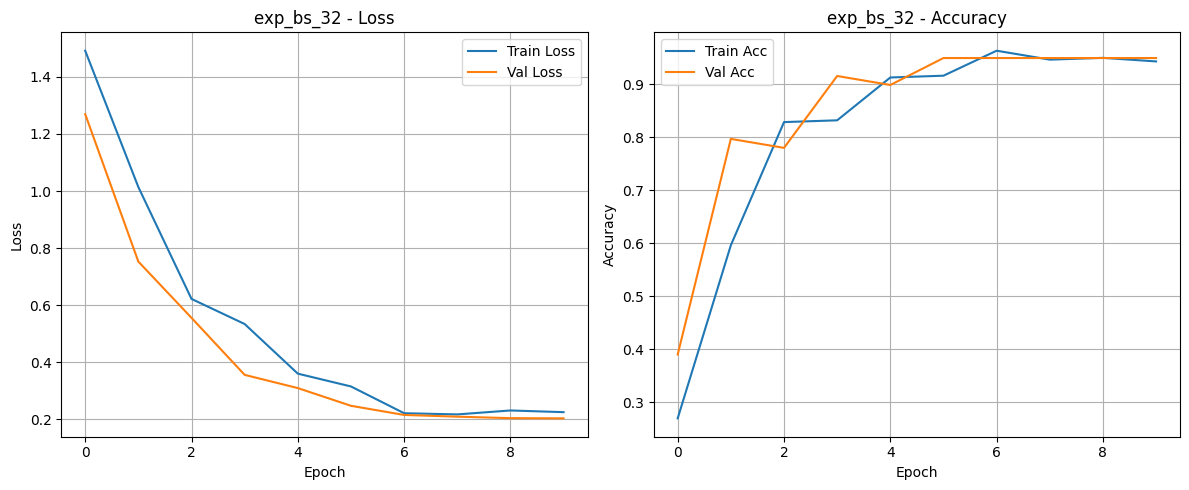


Test Accuracy: 95.00%
Accuracy of kirby       : 90.00%
Accuracy of pink panther: 100.00%
Accuracy of pinkie pie  : 100.00%
Accuracy of slowpoke    : 90.00%


{'train_loss': [1.4921136267658837,
  1.0138443798729868,
  0.6214298768477007,
  0.5333882589332183,
  0.35930729865626454,
  0.3143511193268227,
  0.22049289961856625,
  0.2162995655528624,
  0.23016774368406545,
  0.22417491493803082],
 'train_acc': [tensor(0.2694, dtype=torch.float64),
  tensor(0.5960, dtype=torch.float64),
  tensor(0.8283, dtype=torch.float64),
  tensor(0.8316, dtype=torch.float64),
  tensor(0.9125, dtype=torch.float64),
  tensor(0.9158, dtype=torch.float64),
  tensor(0.9630, dtype=torch.float64),
  tensor(0.9461, dtype=torch.float64),
  tensor(0.9495, dtype=torch.float64),
  tensor(0.9428, dtype=torch.float64)],
 'val_loss': [1.2696403467049033,
  0.7524126646882396,
  0.5550384925583661,
  0.3550418574931258,
  0.30866516848741954,
  0.2465306151721437,
  0.2144252382597681,
  0.20836560705960808,
  0.20313099961159592,
  0.20252282462887844],
 'val_acc': [tensor(0.3898, dtype=torch.float64),
  tensor(0.7966, dtype=torch.float64),
  tensor(0.7797, dtype=torch.fl

In [16]:
    
run_experiment({**CONFIG, 'batch_size': 32, 'experiment_name': 'exp_bs_32'})    


>>> Running experiment: exp_bs_64
Epoch 0/9 | exp_bs_64
----------
train Loss: 1.6809 Acc: 0.2222
val Loss: 1.4569 Acc: 0.3559

Epoch 1/9 | exp_bs_64
----------
train Loss: 1.3456 Acc: 0.3232
val Loss: 1.2409 Acc: 0.4746

Epoch 2/9 | exp_bs_64
----------
train Loss: 1.0960 Acc: 0.5320
val Loss: 0.9407 Acc: 0.6780

Epoch 3/9 | exp_bs_64
----------
train Loss: 0.7937 Acc: 0.8249
val Loss: 0.7408 Acc: 0.7627

Epoch 4/9 | exp_bs_64
----------
train Loss: 0.6778 Acc: 0.8215
val Loss: 0.5878 Acc: 0.8305

Epoch 5/9 | exp_bs_64
----------
train Loss: 0.5402 Acc: 0.8889
val Loss: 0.5157 Acc: 0.8475

Epoch 6/9 | exp_bs_64
----------
train Loss: 0.4530 Acc: 0.8956
val Loss: 0.4663 Acc: 0.8475

Epoch 7/9 | exp_bs_64
----------
train Loss: 0.4015 Acc: 0.8956
val Loss: 0.4526 Acc: 0.8475

Epoch 8/9 | exp_bs_64
----------
train Loss: 0.3832 Acc: 0.9024
val Loss: 0.4500 Acc: 0.8475

Epoch 9/9 | exp_bs_64
----------
train Loss: 0.3785 Acc: 0.9125
val Loss: 0.4432 Acc: 0.8475

Training complete in 1m 1

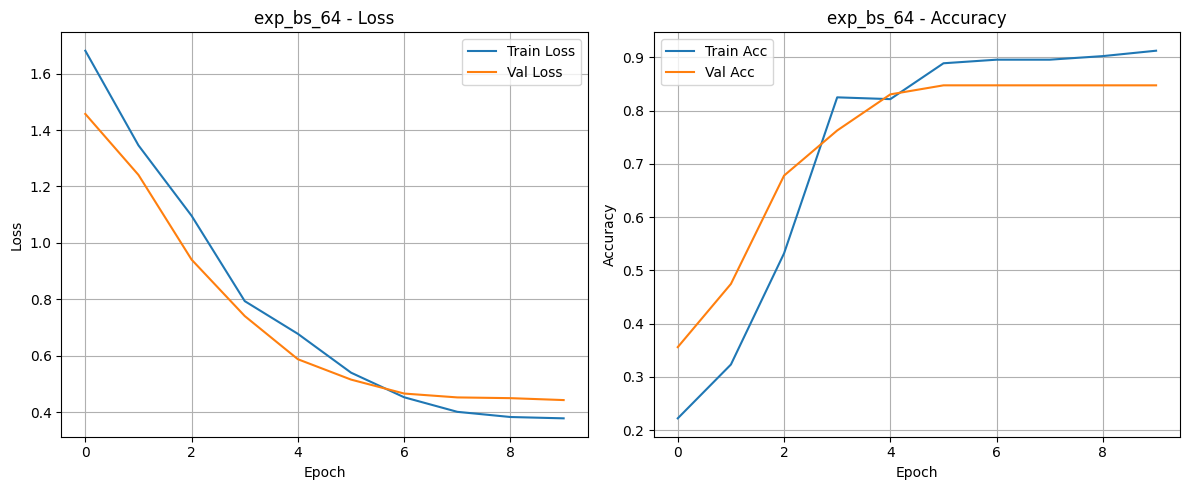


Test Accuracy: 85.00%
Accuracy of kirby       : 80.00%
Accuracy of pink panther: 90.00%
Accuracy of pinkie pie  : 100.00%
Accuracy of slowpoke    : 70.00%


{'train_loss': [1.6809000792326751,
  1.3456159115640403,
  1.0960332606778,
  0.7937051188263428,
  0.677759689112705,
  0.5402410136730181,
  0.4530029293864664,
  0.4014892779817485,
  0.38315378656291,
  0.3784523342394267],
 'train_acc': [tensor(0.2222, dtype=torch.float64),
  tensor(0.3232, dtype=torch.float64),
  tensor(0.5320, dtype=torch.float64),
  tensor(0.8249, dtype=torch.float64),
  tensor(0.8215, dtype=torch.float64),
  tensor(0.8889, dtype=torch.float64),
  tensor(0.8956, dtype=torch.float64),
  tensor(0.8956, dtype=torch.float64),
  tensor(0.9024, dtype=torch.float64),
  tensor(0.9125, dtype=torch.float64)],
 'val_loss': [1.4568969011306763,
  1.2408983707427979,
  0.940712034702301,
  0.7408230900764465,
  0.5878012776374817,
  0.5156950354576111,
  0.4662584960460663,
  0.4525844156742096,
  0.4499663710594177,
  0.4431750774383545],
 'val_acc': [tensor(0.3559, dtype=torch.float64),
  tensor(0.4746, dtype=torch.float64),
  tensor(0.6780, dtype=torch.float64),
  tenso

In [17]:
run_experiment({**CONFIG, 'batch_size': 64, 'experiment_name': 'exp_bs_64'})    


>>> Running experiment: exp_bs_128
Epoch 0/9 | exp_bs_128
----------
train Loss: 1.5841 Acc: 0.2391
val Loss: 1.5419 Acc: 0.3051

Epoch 1/9 | exp_bs_128
----------
train Loss: 1.4478 Acc: 0.2525
val Loss: 1.4045 Acc: 0.4068

Epoch 2/9 | exp_bs_128
----------
train Loss: 1.3121 Acc: 0.3872
val Loss: 1.2326 Acc: 0.4915

Epoch 3/9 | exp_bs_128
----------
train Loss: 1.1610 Acc: 0.5758
val Loss: 1.0579 Acc: 0.5932

Epoch 4/9 | exp_bs_128
----------
train Loss: 0.9943 Acc: 0.6801
val Loss: 0.9075 Acc: 0.6780

Epoch 5/9 | exp_bs_128
----------
train Loss: 0.8533 Acc: 0.7407
val Loss: 0.7882 Acc: 0.7458

Epoch 6/9 | exp_bs_128
----------
train Loss: 0.7406 Acc: 0.7845
val Loss: 0.6941 Acc: 0.7797

Epoch 7/9 | exp_bs_128
----------
train Loss: 0.6495 Acc: 0.8350
val Loss: 0.6809 Acc: 0.7797

Epoch 8/9 | exp_bs_128
----------
train Loss: 0.6551 Acc: 0.8384
val Loss: 0.6664 Acc: 0.7797

Epoch 9/9 | exp_bs_128
----------
train Loss: 0.6685 Acc: 0.7946
val Loss: 0.6544 Acc: 0.7797

Training compl

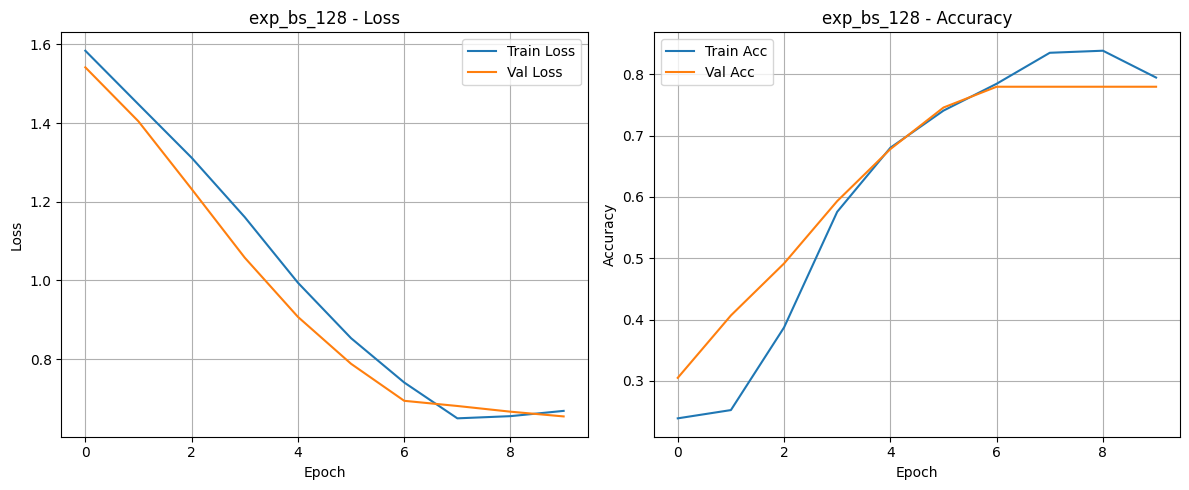


Test Accuracy: 80.00%
Accuracy of kirby       : 100.00%
Accuracy of pink panther: 90.00%
Accuracy of pinkie pie  : 100.00%
Accuracy of slowpoke    : 30.00%


{'train_loss': [1.5841249239565147,
  1.4478342633456092,
  1.3121312411144526,
  1.1610306521457454,
  0.994325603098179,
  0.8532972255539814,
  0.7406091894766297,
  0.649488693736619,
  0.655054570448519,
  0.6684508020628984],
 'train_acc': [tensor(0.2391, dtype=torch.float64),
  tensor(0.2525, dtype=torch.float64),
  tensor(0.3872, dtype=torch.float64),
  tensor(0.5758, dtype=torch.float64),
  tensor(0.6801, dtype=torch.float64),
  tensor(0.7407, dtype=torch.float64),
  tensor(0.7845, dtype=torch.float64),
  tensor(0.8350, dtype=torch.float64),
  tensor(0.8384, dtype=torch.float64),
  tensor(0.7946, dtype=torch.float64)],
 'val_loss': [1.541900634765625,
  1.4044820070266724,
  1.232585072517395,
  1.0579123497009277,
  0.90749192237854,
  0.7881799936294556,
  0.6940677165985107,
  0.6809025406837463,
  0.6664019227027893,
  0.654358983039856],
 'val_acc': [tensor(0.3051, dtype=torch.float64),
  tensor(0.4068, dtype=torch.float64),
  tensor(0.4915, dtype=torch.float64),
  tensor

In [18]:
run_experiment({**CONFIG, 'batch_size': 128, 'experiment_name': 'exp_bs_128'})    

Исследование режима обучения


>>> Running experiment: exp_feature_extract
Epoch 0/9 | exp_feature_extract
----------
train Loss: 1.3508 Acc: 0.3569
val Loss: 1.0452 Acc: 0.5254

Epoch 1/9 | exp_feature_extract
----------
train Loss: 0.9159 Acc: 0.7003
val Loss: 0.6983 Acc: 0.7458

Epoch 2/9 | exp_feature_extract
----------
train Loss: 0.6147 Acc: 0.8283
val Loss: 0.5311 Acc: 0.8814

Epoch 3/9 | exp_feature_extract
----------
train Loss: 0.6186 Acc: 0.8114
val Loss: 0.4805 Acc: 0.8475

Epoch 4/9 | exp_feature_extract
----------
train Loss: 0.5265 Acc: 0.8451
val Loss: 0.5009 Acc: 0.8305

Epoch 5/9 | exp_feature_extract
----------
train Loss: 0.5130 Acc: 0.8249
val Loss: 0.3882 Acc: 0.8983

Epoch 6/9 | exp_feature_extract
----------
train Loss: 0.4694 Acc: 0.8418
val Loss: 0.3479 Acc: 0.9322

Epoch 7/9 | exp_feature_extract
----------
train Loss: 0.4212 Acc: 0.8889
val Loss: 0.3421 Acc: 0.9322

Epoch 8/9 | exp_feature_extract
----------
train Loss: 0.3616 Acc: 0.9226
val Loss: 0.3440 Acc: 0.9322

Epoch 9/9 | exp_fea

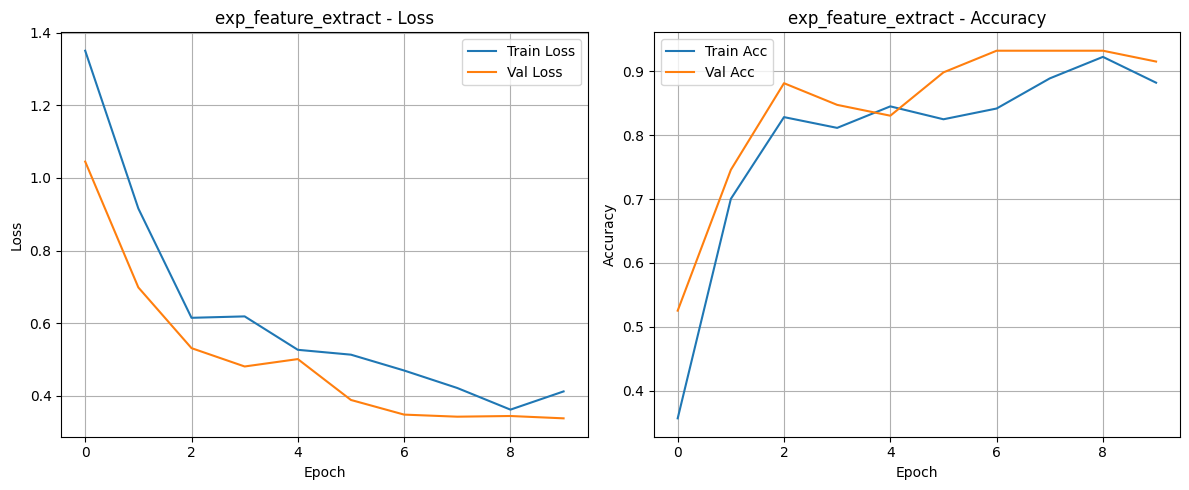


Test Accuracy: 92.50%
Accuracy of kirby       : 80.00%
Accuracy of pink panther: 100.00%
Accuracy of pinkie pie  : 100.00%
Accuracy of slowpoke    : 90.00%


In [19]:
run_experiment({**CONFIG, 'mode': 'feature_extract', 'experiment_name': 'exp_feature_extract'})
    
plt.ioff()
